In [1]:
import os
import cv2
import torch
import importlib
import dataset
importlib.reload(dataset)
from dataset import RGBMiningDataset
from model import MultiInputCNN, PretrainedResNet
#from model import PretrainedResNet
from train import train_model

In [4]:
##data paths
train_dir = 'data/train'
val_dir = 'data/val'
#ndvi_dir = 'data/ndvi'
#ndwi_dir = 'data/ndwi'

In [6]:
##map class to numeric labels
##class_to_idx = {'Garimpo': 0, 'Rios_Floresta': 1}

In [8]:
##dataset objects
train_dataset = RGBMiningDataset(train_dir)
val_dataset = RGBMiningDataset(val_dir)

In [10]:
## model
input_channels = 3

In [12]:
#model = MultiInputCNN(input_channels=input_channels, num_classes=10)

##ResNet 
model = PretrainedResNet(num_classes=10)

C:\Users\aduko\anaconda3\envs\mining-env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\aduko\anaconda3\envs\mining-env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
##specify gpu usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

PretrainedResNet(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [ ]:
##train
model = train_model(model, train_dataset, val_dataset, device)

##my cnn model
#torch.save(model.state_dict(), "illegal_mining_model.pt")

##ResNet
##only saved weights
torch.save(model.state_dict(), "resnet_model.pt")

Epoch 1, Train Loss: 0.7671, Val Accuracy: 83.34%
Epoch 2, Train Loss: 0.4061, Val Accuracy: 84.41%
Epoch 3, Train Loss: 0.3420, Val Accuracy: 90.39%
Epoch 4, Train Loss: 0.2955, Val Accuracy: 87.17%
Epoch 5, Train Loss: 0.2617, Val Accuracy: 91.65%
Epoch 6, Train Loss: 0.1983, Val Accuracy: 92.81%
Epoch 7, Train Loss: 0.1862, Val Accuracy: 92.67%
Epoch 8, Train Loss: 0.1477, Val Accuracy: 89.73%
Epoch 9, Train Loss: 0.1378, Val Accuracy: 92.72%
Epoch 10, Train Loss: 0.1427, Val Accuracy: 93.51%
Epoch 11, Train Loss: 0.1031, Val Accuracy: 92.95%
Epoch 12, Train Loss: 0.1117, Val Accuracy: 93.79%
Epoch 13, Train Loss: 0.1011, Val Accuracy: 92.07%
Epoch 14, Train Loss: 0.0932, Val Accuracy: 93.84%
Epoch 15, Train Loss: 0.0667, Val Accuracy: 93.89%
Epoch 16, Train Loss: 0.0811, Val Accuracy: 92.58%
Epoch 17, Train Loss: 0.0834, Val Accuracy: 93.75%
Epoch 18, Train Loss: 0.0736, Val Accuracy: 94.07%
Epoch 19, Train Loss: 0.0610, Val Accuracy: 93.70%
Epoch 20, Train Loss: 0.0639, Val Accura

## Test Model on an image

In [3]:
def predict_image(img_path, model, device):
    class_map = {
        0: 'Bareland', 
        1: 'Beach', 
        2: 'Dense-Residential', 
        3: 'Desert',
        4: 'Farmland', 
        5: 'Forest', 
        6: 'Illegal-Mining', 
        7: 'Legal-Mining', 
        8: 'Mountain', 
        9: 'Sparse-Residential'
    }
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
    #img = img.unsqueeze(0).to(device)

    ##normalize for resnet
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = (img - mean) / std

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        pred_idx = torch.argmax(output, dim=1).item()
        pred_label = class_map.get(pred_idx, "Unknown")
    
    return f"The prediction is {pred_idx}, which corresponds to {pred_label}"

In [5]:
print(predict_image("test-images/Kups.png", model, device))

NameError: name 'model' is not defined

## Evaluation 

In [46]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

In [48]:
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def evaluate_model(model, val_loader, device, class_map):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    target_names = [class_map[i] for i in range(len(class_map))]
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names,
                yticklabels=target_names)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

In [50]:
class_map = {
    0: 'Bareland',
    1: 'Beach',
    2: 'Dense-Residential',
    3: 'Desert',
    4: 'Farmland',
    5: 'Forest',
    6: 'Illegal-Mining',
    7: 'Legal-Mining',
    8: 'Mountain',
    9: 'Sparse-Residential'
}


Classification Report:

                    precision    recall  f1-score   support

          Bareland       0.86      0.93      0.89       231
             Beach       0.99      0.98      0.99       180
 Dense-Residential       0.93      0.99      0.96       230
            Desert       0.94      0.93      0.94       217
          Farmland       0.98      0.98      0.98       234
            Forest       0.98      0.99      0.98       150
    Illegal-Mining       1.00      0.97      0.98       217
      Legal-Mining       0.94      0.90      0.92       232
          Mountain       0.95      0.99      0.97       239
Sparse-Residential       0.94      0.87      0.90       213

          accuracy                           0.95      2143
         macro avg       0.95      0.95      0.95      2143
      weighted avg       0.95      0.95      0.95      2143



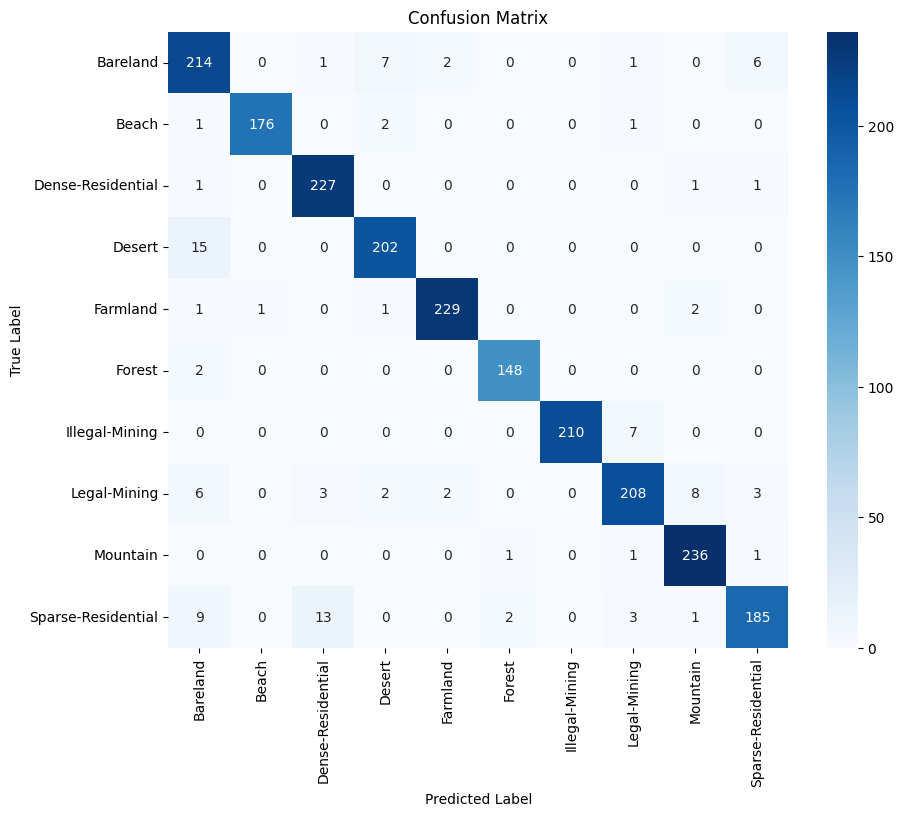

In [52]:
evaluate_model(model, val_loader, device, class_map)

In [7]:
x = 1
y = 2

print(x+y)

3
